In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # Model
    FEMModel,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m, mm, N,
    # Parameters
    globalParameters,
)


import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh
np.set_printoptions(suppress=True, precision=6, linewidth=400)


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. Jose Abell

  Version 1.2.0                        (c) 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen
  
  ********* (>'-')> Ladruno4ever  *********



In [3]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'batman'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [4]:
# Material
Steel=Material( name='Steel',
                E=2000,
                nu=0.30,
                rho=1.25*tf/m**3*0)

# Sections
F1=Membrane(    name='F1',
                thickness=15,
                material=Steel)

# Dictionaries
section_dictionary={17:F1,
                        }

restrain_dictionary={18:['r', 'f']}

load_dictionary = {
                19:   {'value': 10, 'direction': 'x'},   
                20:   {'value': 10, 'direction': '-x'},   

}

In [5]:
# read mesh 
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (2681 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1        -1.0000         1.0000         0.0000
       2        -0.7500         3.0000         0.0000
       3        -0.5000         2.2500         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      18      0   'support'
      19      1   'load_p_x'
      20      1   'load_m_x'
      17      2   'steel'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      18      0       15          1            2   'su

In [6]:
model = FEMModel(
    mesh                = mesh,
    section_dictionary  = {},
    restrain_dictionary = {},
    load_dictionary     = load_dictionary,
    element_class_map   = None,       # OpenSees only
    analysis_type       = '3D',
    consistent_loads    = False,
)


  FEM MODEL SUMMARY
--------------------------------------------------------------------------------
  Analysis type    : 3D
  Nodes            : 2681
  system_nDof      : 5362
  Elements         : None (OpenSees)
  Steps FEM        : 0
  Steps OpenSees   : 0

  --- Sections ---

  --- Restrained nodes ---

  --- Loaded nodes (dim=0) ---

  --- Load vector ---
  Non-zero DOFs in F_load : 104
  Total applied force     : -0.0000 (x)  0.0000 (y)
--------------------------------------------------------------------------------



In [7]:
# Mesh diagnostics
model.check_mesh()


  MESH DIAGNOSTICS
--------------------------------------------------------------------------------
  Nodes            : 2681
  system_nDof      : 5362
  Elements         : None (OpenSees)
  Physical groups  : 4

  --- Orphan nodes ---
  OK — no orphan nodes

  --- Physical groups ---
      ID   Dim  Name                    Elements     Nodes  Section
  ------  ----  --------------------  ----------  --------  ----------
      18     0  support                        2         2  N/A
      19     1  load_p_x                      51        52  N/A
      20     1  load_m_x                      51        52  N/A
      17     2  steel                       5068      2681  MISSING

  --- Restrained nodes ---
     Tag             x             y  Condition
  ------  ------------  ------------  ------------

  --- Load summary ---
  Non-zero DOFs    : 104
  Total Fx         : -0.0000
  Total Fy         : +0.0000
--------------------------------------------------------------------------------

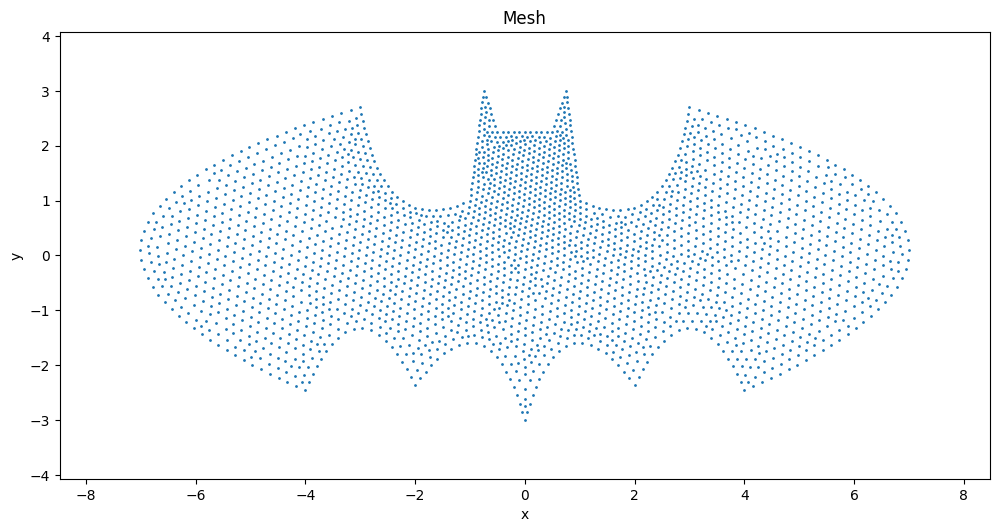

In [8]:
# Plot mesh
model.plot(
    step                = -1,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 8),
)

## Opensees

In [9]:
import openseespy.opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder', '-ndm', 2, '-ndf', 2)


In [10]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y)

In [11]:
# Boundary conditions
fixed_nodes = set()
for tag in mesh.physical_groups['support'].nodes:
    if tag not in fixed_nodes:
        fixed_nodes.add(tag)
        # ops.fix(tag, 1, 1, 1, 1, 1, 1)
        ops.fix(tag, 1, 1, 1)

In [12]:
# Material
solidMaterialTag = 1

ops.nDMaterial('ElasticIsotropic', solidMaterialTag,
               Steel.E,
               Steel.nu,
               Steel.rho)

In [13]:
group = mesh.physical_groups['steel'].elements
for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
    n1, n2, n3 = conn
    ops.element('tri31', elem_tag, n1, n2, n3, F1.thickness, 'PlaneStress', solidMaterialTag)

Tri31 - Written by Roozbeh G. Mikola and N.Sitar, UC Berkeley


<Axes: >

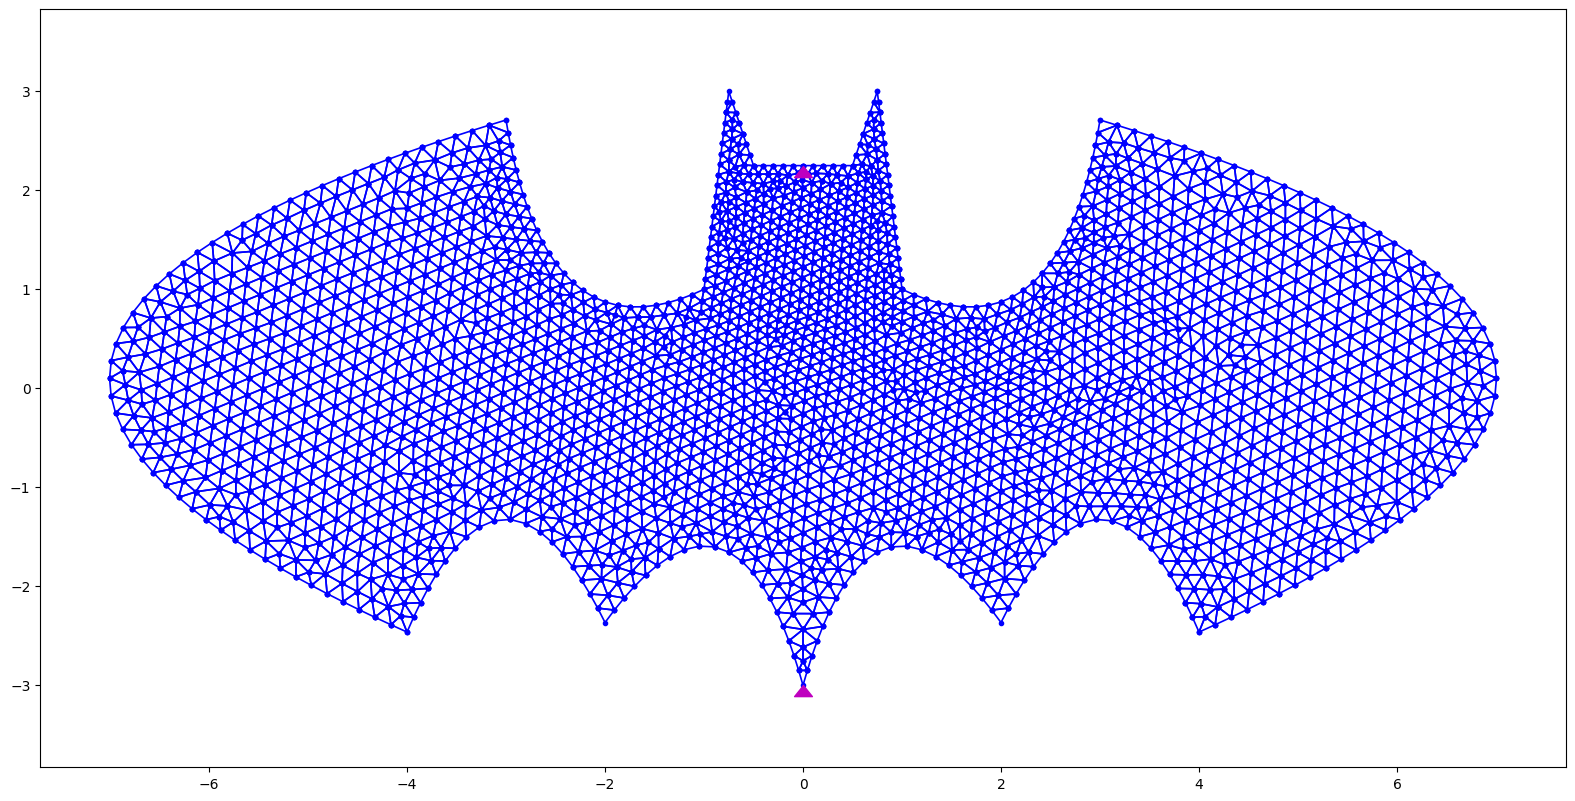

In [14]:
opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [15]:
# Loads
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)

for tag, force in model.F_nodal.items():
    if np.any(np.abs(force) > 0):
        ops.load(tag, *force.tolist())

In [16]:
NstepGravity=10
DGravity=1/NstepGravity

ops.system("FullGeneral")
ops.numberer("RCM") 
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity )
ops.test("NormUnbalance", 1.0e-6, 100 , 0)
ops.algorithm("Newton")
ops.analysis("Static")

ops.analyze(NstepGravity)


ops.analyze(NstepGravity)
# save last step
model.set_results_opensees(ops, step=0, time=1.0)

FEMResult(step=0, time=1.0000)

In [17]:
# Static results in gmsh — last step
model.plot2gmsh(
    step           = -1,
    source         = 'opensees',
    disp_factor    = 2,
    show_disp      = True,
    show_loads     = True,
    show_reactions = True,
    show_stress    = True,
    show_strain    = True,
    show_vm        = True,
    show_averaged  = True,
)

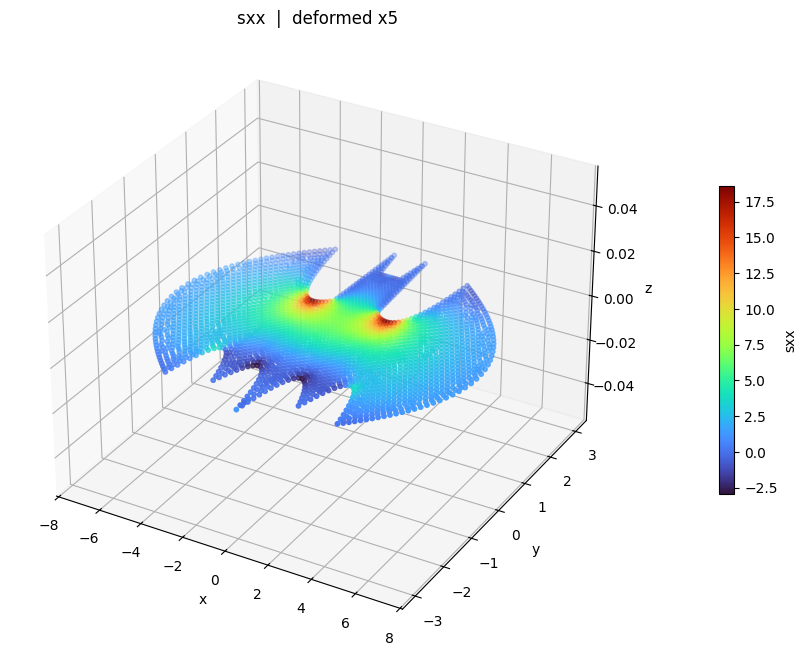

In [26]:
# Plot field
model.plot_field(
    component           = 'sxx',        # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy'
    source              = 'opensees',
    step                = -1,
    # result_type         = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 5,
    cmap                = 'turbo',
    # show_element_edges  = True,
    # show_supports       = True,
    figsize             = (12, 8),
)

Text(0.5, 1.0, 'sxx')

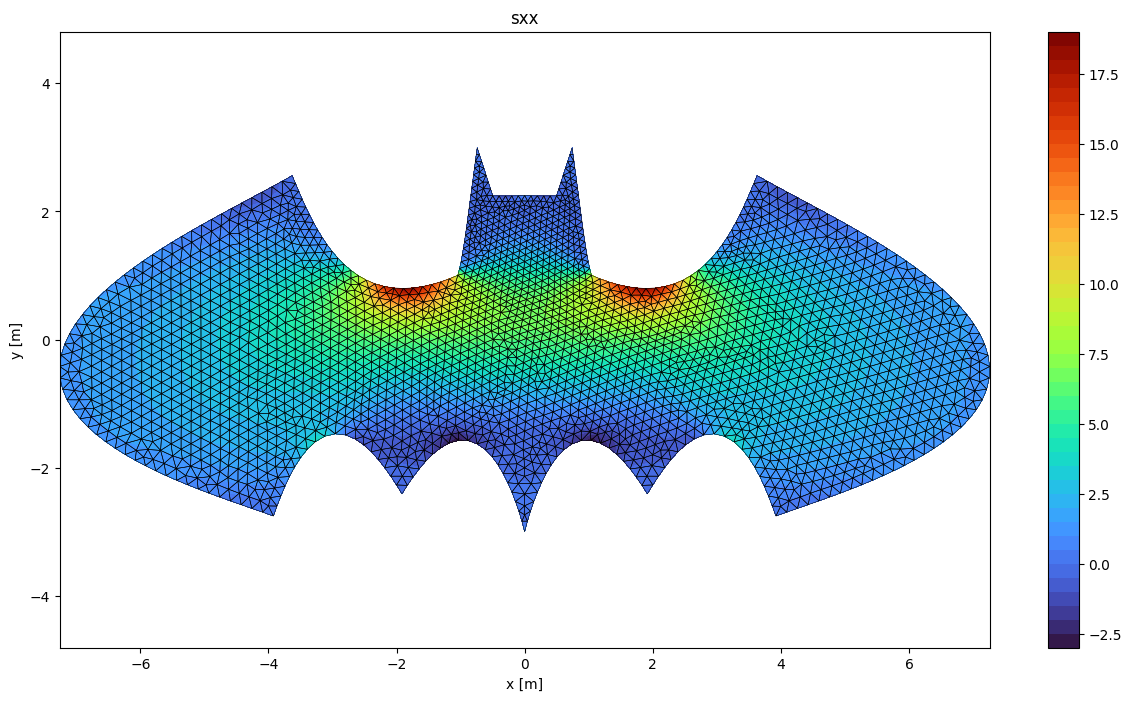

In [19]:
jstr = 'sxx'
# jstr = 'syy'
# jstr = 'sxy'
# jstr = 'vmis'
# jstr = 's1'
# jstr = 's2'
# jstr = 'angle'

plt.figure(figsize=(15, 8))
opsv.plot_stress(jstr)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title(f'{jstr}')